# 05_tsne_umap_mel_nv

Feature-space visualization for clean MEL vs NV PanDerm models.

Goal:
- extract image-level features from selected PanDerm transformer blocks,
- compare CLS HA 0.5 and GAP HA 0.25 in one notebook,
- visualize the feature space with t-SNE and optionally UMAP,
- color points by true label, prediction, correctness, and MEL probability,
- compute simple feature-space quality metrics: kNN accuracy, silhouette score, and linear probe balanced accuracy.

Interpretation:
- This is exploratory evidence only.
- It can show whether MEL/NV become separable in representation space.
- It does **not** prove that the model learned clinically meaningful features.
- CAM/Finer-CAM still answers where the model focuses; this notebook answers whether global representations separate the classes.


## 0. Configuration

Recommended first run:
- `SAMPLE_MODE = "all_test"`
- `SELECTED_BLOCKS = [-1, -2, -4, -6, -8, -10, -12]`
- keep both CLS and GAP scenarios

If runtime is too high, set `MAX_SAMPLES = 300` first.


In [1]:
from pathlib import Path
import sys
import os
import random
import warnings
from collections import OrderedDict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    silhouette_score,
)
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

# Notebook location: notebooks/mel_nv/05_tsne_umap_mel_nv.ipynb
# Local notebook:
# REPO_ROOT = Path("../..").resolve() # local notebook
REPO_ROOT = Path("..").resolve() # ubelix notebook
REPO_ROOT = REPO_ROOT / "master-thesis"

# UBELIX notebook alternative. Uncomment if needed:
# REPO_ROOT = Path("..").resolve() / "master-thesis"

PANDERM_CLASSIFICATION_DIR = REPO_ROOT / "external" / "PanDerm" / "classification"
if str(PANDERM_CLASSIFICATION_DIR) not in sys.path:
    sys.path.insert(0, str(PANDERM_CLASSIFICATION_DIR))

CSV_PATH = REPO_ROOT / "data" / "HAM10000" / "mel_nv" / "ham_mel_nv_clean.csv"
IMG_DIR = REPO_ROOT / "data" / "HAM10000"

NB_CLASSES = 2
CLASS_NAMES = ["MEL", "NV"]
LABEL_COL = "binary_label"      # MEL=0, NV=1 in your CSV
GT_COL = "gt_label"
IMAGE_COL = "image_rel_path"
ID_COL = "image_id"

IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 4
SEED = 42

# Data choice
SAMPLE_MODE = "all_test"  # "all_test" or "qualitative"
QUAL_CSV = REPO_ROOT / "data" / "HAM10000" / "mel_nv" / "ham_mel_nv_clean_qualitative_10_per_class_seed42.csv"
MAX_SAMPLES = None        # e.g. 300 for debugging, None for all selected rows

# Blocks to inspect.
# Good connection to your CAM block-sensitivity notebook.
SELECTED_BLOCKS = [-1, -2, -4, -6, -8, -10, -12]

# Feature extraction mode for each block:
# - "matching_pooling": CLS scenario uses CLS token; GAP scenario uses mean patch pooling.
# - "gap_patch_tokens": both scenarios use mean patch tokens.
# - "cls_token": both scenarios use CLS token.
FEATURE_MODE = "matching_pooling"

# t-SNE/UMAP settings
RUN_TSNE = True
RUN_UMAP = True   # If umap-learn is not installed, notebook will skip it safely.
PCA_DIM_BEFORE_TSNE = 50
TSNE_PERPLEXITY = 30

# Metrics
KNN_K = 5
LINEAR_PROBE_MAX_ITER = 1000

OUT_ROOT = REPO_ROOT / "outputs" / "mel_nv" / "tsne_umap_feature_space"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

SCENARIOS = [
    {
        "name": "CLS HA 0.5",
        "short_name": "cls_ha05",
        "checkpoint": REPO_ROOT / "external" / "checkpoints4" / "checkpoint-best-cls.pth",
        "use_mean_pooling": False,
        "pooling_name": "CLS token pooling",
    },
    {
        "name": "GAP HA 0.25",
        "short_name": "gap_ha025",
        "checkpoint": REPO_ROOT / "external" / "checkpoints4" / "checkpoint-best-gap.pth",
        "use_mean_pooling": True,
        "pooling_name": "GAP / mean pooling",
    },
]

print("REPO_ROOT:", REPO_ROOT)
print("CSV exists:", CSV_PATH.exists(), CSV_PATH)
print("QUAL_CSV exists:", QUAL_CSV.exists(), QUAL_CSV)
print("IMG_DIR exists:", IMG_DIR.exists(), IMG_DIR)
print("OUT_ROOT:", OUT_ROOT)
print("FEATURE_MODE:", FEATURE_MODE)
print("SELECTED_BLOCKS:", SELECTED_BLOCKS)
for s in SCENARIOS:
    print("\n", s["name"])
    print("  checkpoint exists:", Path(s["checkpoint"]).exists(), s["checkpoint"])
    print("  use_mean_pooling:", s["use_mean_pooling"])


REPO_ROOT: /storage/homefs/cn21m021/projects/master-thesis
CSV exists: True /storage/homefs/cn21m021/projects/master-thesis/data/HAM10000/mel_nv/ham_mel_nv_clean.csv
QUAL_CSV exists: True /storage/homefs/cn21m021/projects/master-thesis/data/HAM10000/mel_nv/ham_mel_nv_clean_qualitative_10_per_class_seed42.csv
IMG_DIR exists: True /storage/homefs/cn21m021/projects/master-thesis/data/HAM10000
OUT_ROOT: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space
FEATURE_MODE: matching_pooling
SELECTED_BLOCKS: [-1, -2, -4, -6, -8, -10, -12]

 CLS HA 0.5
  checkpoint exists: True /storage/homefs/cn21m021/projects/master-thesis/external/checkpoints4/checkpoint-best-cls.pth
  use_mean_pooling: False

 GAP HA 0.25
  checkpoint exists: True /storage/homefs/cn21m021/projects/master-thesis/external/checkpoints4/checkpoint-best-gap.pth
  use_mean_pooling: True


In [2]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


DEVICE: cuda
GPU: NVIDIA GeForce RTX 4090


## 1. Dataset and transforms

In [3]:
class CSVDermDataset(Dataset):
    def __init__(self, df, root_path, transform=None, image_col="image_rel_path", label_col="binary_label"):
        self.df = df.reset_index(drop=True)
        self.root_path = Path(root_path)
        self.transform = transform
        self.image_col = image_col
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def resolve_path(self, value):
        p = Path(str(value))
        if p.is_absolute():
            return p
        return (self.root_path / p).resolve()

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.resolve_path(row[self.image_col])
        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        label = int(row[self.label_col])
        image_id = str(row[ID_COL]) if ID_COL in row.index else Path(str(row[self.image_col])).stem
        gt_label = str(row[GT_COL]) if GT_COL in row.index else str(label)
        return img, label, image_id, gt_label


eval_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

if SAMPLE_MODE == "qualitative":
    df = pd.read_csv(QUAL_CSV, low_memory=False).copy()
elif SAMPLE_MODE == "all_test":
    df = pd.read_csv(CSV_PATH, low_memory=False)
    df = df[df["split"].astype(str).str.lower().eq("test")].copy()
    df = df.sort_values([GT_COL, ID_COL]).reset_index(drop=True)
else:
    raise ValueError("SAMPLE_MODE must be 'all_test' or 'qualitative'.")

required_cols = {IMAGE_COL, LABEL_COL, GT_COL, ID_COL}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

if MAX_SAMPLES is not None and len(df) > MAX_SAMPLES:
    df = df.sample(n=int(MAX_SAMPLES), random_state=SEED).reset_index(drop=True)

print("Rows:", len(df))
display(df[[ID_COL, GT_COL, LABEL_COL, IMAGE_COL]].head())
display(df[GT_COL].value_counts())

ds = CSVDermDataset(df, IMG_DIR, transform=eval_transform, image_col=IMAGE_COL, label_col=LABEL_COL)
loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


Rows: 1021


,image_id,gt_label,binary_label,image_rel_path
0,ISIC_0024459,MEL,0,images/ISIC_0024459.jpg
1,ISIC_0024571,MEL,0,images/ISIC_0024571.jpg
2,ISIC_0024624,MEL,0,images/ISIC_0024624.jpg
3,ISIC_0024640,MEL,0,images/ISIC_0024640.jpg
4,ISIC_0024756,MEL,0,images/ISIC_0024756.jpg


gt_label
NV     951
MEL     70
Name: count, dtype: int64

## 2. Load PanDerm models

In [4]:
from models.modeling_finetune import panderm_base_patch16_224_finetune, panderm_large_patch16_224_finetune


def infer_variant_from_state_dict(sd: dict) -> str:
    for key in ["cls_token", "module.cls_token", "model.cls_token"]:
        if key in sd:
            dim = sd[key].shape[-1]
            if dim == 768:
                return "base"
            if dim == 1024:
                return "large"
    return "base"


def build_model(num_classes: int, use_mean_pooling: bool, variant: str = "base"):
    common_kwargs = dict(
        pretrained=False,
        num_classes=num_classes,
        drop_rate=0.0,
        drop_path_rate=0.0,
        attn_drop_rate=0.0,
        drop_block_rate=None,
        use_mean_pooling=use_mean_pooling,
        init_scale=1.0,
        use_rel_pos_bias=False,
        init_values=0.1,
        lin_probe=False,
    )
    if variant == "base":
        return panderm_base_patch16_224_finetune(**common_kwargs)
    elif variant == "large":
        return panderm_large_patch16_224_finetune(**common_kwargs)
    else:
        raise ValueError(f"Unknown variant: {variant}")


def unwrap_state_dict(ckpt):
    if isinstance(ckpt, dict):
        for key in ["model", "state_dict", "module"]:
            if key in ckpt and isinstance(ckpt[key], dict):
                ckpt = ckpt[key]
                break
    new_sd = OrderedDict()
    for k, v in ckpt.items():
        if k.startswith("module."):
            k = k[len("module."):]
        if k.startswith("backbone."):
            k = k[len("backbone."):]
        new_sd[k] = v
    return new_sd


def load_model_for_scenario(scenario: dict):
    ckpt = torch.load(scenario["checkpoint"], map_location="cpu")
    sd = unwrap_state_dict(ckpt)
    variant = infer_variant_from_state_dict(sd)
    model = build_model(NB_CLASSES, scenario["use_mean_pooling"], variant=variant)
    missing, unexpected = model.load_state_dict(sd, strict=False)

    print("\nLoaded", scenario["name"])
    print("  variant:", variant)
    print("  missing keys:", len(missing))
    print("  unexpected keys:", len(unexpected))
    if len(missing) < 20:
        print("  missing:", missing)
    if len(unexpected) < 20:
        print("  unexpected:", unexpected)

    model.to(DEVICE)
    model.eval()
    for p in model.parameters():
        p.requires_grad = False

    print("  blocks:", len(model.blocks))
    print("  patch grid:", model.patch_embed.patch_shape)
    print("  use_mean_pooling:", model.use_mean_pooling)
    return model


def normalize_block_indices(selected_blocks, num_blocks):
    out = []
    for b in selected_blocks:
        idx = b if b >= 0 else num_blocks + b
        if idx < 0 or idx >= num_blocks:
            raise ValueError(f"Block {b} resolves to {idx}, outside 0..{num_blocks-1}")
        out.append(idx)
    return out


## 3. Feature extraction

For each selected block, the notebook stores one image-level vector per image.

Default `FEATURE_MODE = "matching_pooling"`:
- CLS model: use the CLS token from that block
- GAP model: use the mean of patch tokens from that block

This matches how each classifier was trained.


In [5]:
@torch.no_grad()
def extract_block_features_and_predictions(model, loader, block_indices, scenario):
    storage = {idx: [] for idx in block_indices}
    labels = []
    image_ids = []
    gt_labels = []
    pred_labels = []
    probs_all = []
    hooks = []

    def make_hook(idx):
        def hook(module, inputs, output):
            # output shape: [B, 1 + num_patches, C]
            if FEATURE_MODE == "matching_pooling":
                if scenario["use_mean_pooling"]:
                    feat = output[:, 1:, :].mean(dim=1)
                else:
                    feat = output[:, 0, :]
            elif FEATURE_MODE == "gap_patch_tokens":
                feat = output[:, 1:, :].mean(dim=1)
            elif FEATURE_MODE == "cls_token":
                feat = output[:, 0, :]
            else:
                raise ValueError(f"Unknown FEATURE_MODE: {FEATURE_MODE}")
            storage[idx].append(feat.detach().cpu().float())
        return hook

    for idx in block_indices:
        hooks.append(model.blocks[idx].register_forward_hook(make_hook(idx)))

    try:
        for batch_idx, (images, y, ids, gt) in enumerate(loader):
            images = images.to(DEVICE, non_blocking=True)
            logits = model(images)
            probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
            pred = probs.argmax(axis=1)

            labels.append(y.cpu().numpy())
            image_ids.extend(list(ids))
            gt_labels.extend(list(gt))
            pred_labels.extend(pred.tolist())
            probs_all.append(probs)

            if (batch_idx + 1) % 10 == 0:
                print(f"Processed {batch_idx + 1}/{len(loader)} batches")
    finally:
        for h in hooks:
            h.remove()

    features = {idx: torch.cat(storage[idx], dim=0).numpy() for idx in block_indices}
    labels = np.concatenate(labels, axis=0)
    probs_all = np.concatenate(probs_all, axis=0)
    pred_labels = np.asarray(pred_labels)

    meta = pd.DataFrame({
        "image_id": image_ids,
        "gt_label": gt_labels,
        "y_true": labels,
        "y_pred": pred_labels,
        "pred_label": [CLASS_NAMES[i] for i in pred_labels],
        "correct": labels == pred_labels,
        "mel_probability": probs_all[:, 0],
        "nv_probability": probs_all[:, 1],
        "prediction_confidence": probs_all.max(axis=1),
    })
    return features, meta


FEATURE_PACKS = {}

for scenario in SCENARIOS:
    print("\n" + "#" * 100)
    print("Extracting features:", scenario["name"])
    print("#" * 100)

    model = load_model_for_scenario(scenario)
    block_indices = normalize_block_indices(SELECTED_BLOCKS, len(model.blocks))
    print("Selected/resolved blocks:", list(zip(SELECTED_BLOCKS, block_indices)))

    features, meta = extract_block_features_and_predictions(model, loader, block_indices, scenario)

    scenario_out = OUT_ROOT / scenario["short_name"]
    scenario_out.mkdir(parents=True, exist_ok=True)
    meta.to_csv(scenario_out / "feature_meta_predictions.csv", index=False)

    for selected, idx in zip(SELECTED_BLOCKS, block_indices):
        np.save(scenario_out / f"features_block_{selected}.npy", features[idx])
        print(f"block {selected:>3} / idx {idx:>2}:", features[idx].shape)

    print("Prediction summary:")
    print("  accuracy:", accuracy_score(meta["y_true"], meta["y_pred"]))
    print("  balanced_accuracy:", balanced_accuracy_score(meta["y_true"], meta["y_pred"]))

    FEATURE_PACKS[scenario["short_name"]] = {
        "scenario": scenario,
        "features": {selected: features[idx] for selected, idx in zip(SELECTED_BLOCKS, block_indices)},
        "meta": meta,
        "out_dir": scenario_out,
    }

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()



####################################################################################################
Extracting features: CLS HA 0.5
####################################################################################################

Loaded CLS HA 0.5
  variant: base
  missing keys: 0
  unexpected keys: 0
  missing: []
  unexpected: []
  blocks: 12
  patch grid: (14, 14)
  use_mean_pooling: False
Selected/resolved blocks: [(-1, 11), (-2, 10), (-4, 8), (-6, 6), (-8, 4), (-10, 2), (-12, 0)]
Processed 10/16 batches
block  -1 / idx 11: (1021, 768)
block  -2 / idx 10: (1021, 768)
block  -4 / idx  8: (1021, 768)
block  -6 / idx  6: (1021, 768)
block  -8 / idx  4: (1021, 768)
block -10 / idx  2: (1021, 768)
block -12 / idx  0: (1021, 768)
Prediction summary:
  accuracy: 0.9226248775710089
  balanced_accuracy: 0.9386134895598619

####################################################################################################
Extracting features: GAP HA 0.25
##############################

## 4. Feature-space metrics

These metrics are more useful for deciding whether a block separates MEL/NV than the t-SNE image alone.

- `knn_balanced_accuracy`: local neighborhood separability
- `linear_probe_balanced_accuracy`: linear separability of image-level features
- `silhouette`: cluster separation by true label after scaling


In [6]:
def compute_feature_metrics(X, y, seed=42):
    X = np.asarray(X)
    y = np.asarray(y)

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    # kNN on same dataset is exploratory, not a strict train/test estimate.
    # It asks whether local neighbors tend to share the same label.
    knn = KNeighborsClassifier(n_neighbors=KNN_K, weights="distance")
    knn.fit(Xs, y)
    pred_knn = knn.predict(Xs)

    # Linear probe on same dataset is also exploratory.
    # It helps compare blocks under the same setting.
    lin = LogisticRegression(
        max_iter=LINEAR_PROBE_MAX_ITER,
        class_weight="balanced",
        solver="lbfgs",
    )
    lin.fit(Xs, y)
    pred_lin = lin.predict(Xs)

    if len(np.unique(y)) == 2 and len(y) > 2:
        try:
            sil = float(silhouette_score(Xs, y, metric="euclidean"))
        except Exception:
            sil = np.nan
    else:
        sil = np.nan

    # Simple centroid distance in standardized space.
    c0 = Xs[y == 0].mean(axis=0)
    c1 = Xs[y == 1].mean(axis=0)
    centroid_distance = float(np.linalg.norm(c0 - c1))

    return {
        "knn_accuracy": float(accuracy_score(y, pred_knn)),
        "knn_balanced_accuracy": float(balanced_accuracy_score(y, pred_knn)),
        "linear_probe_accuracy": float(accuracy_score(y, pred_lin)),
        "linear_probe_balanced_accuracy": float(balanced_accuracy_score(y, pred_lin)),
        "silhouette": sil,
        "centroid_distance": centroid_distance,
    }


metric_rows = []
for short_name, pack in FEATURE_PACKS.items():
    y = pack["meta"]["y_true"].values
    scenario = pack["scenario"]
    for block, X in pack["features"].items():
        m = compute_feature_metrics(X, y, seed=SEED)
        metric_rows.append({
            "model": scenario["name"],
            "short_name": short_name,
            "pooling": scenario["pooling_name"],
            "feature_mode": FEATURE_MODE,
            "block": block,
            **m,
        })

feature_metrics_df = pd.DataFrame(metric_rows)
feature_metrics_path = OUT_ROOT / "feature_space_metrics.csv"
feature_metrics_df.to_csv(feature_metrics_path, index=False)
print("Saved:", feature_metrics_path)
display(feature_metrics_df.sort_values(["model", "knn_balanced_accuracy"], ascending=[True, False]))


Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/feature_space_metrics.csv


,model,short_name,pooling,feature_mode,block,knn_accuracy,knn_balanced_accuracy,linear_probe_accuracy,linear_probe_balanced_accuracy,silhouette,centroid_distance
0,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling,-1,1.0,1.0,1.0,1.0,0.179701,26.410072
1,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling,-2,1.0,1.0,1.0,1.0,0.163271,23.141247
2,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling,-4,1.0,1.0,1.0,1.0,0.125496,19.932720
3,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling,-6,1.0,1.0,1.0,1.0,0.134970,19.051201
4,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling,-8,1.0,1.0,1.0,1.0,0.116370,19.393196
5,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling,-10,1.0,1.0,1.0,1.0,0.147353,22.727320
6,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling,-12,1.0,1.0,1.0,1.0,0.237016,26.343483
7,GAP HA 0.25,gap_ha025,GAP / mean pooling,matching_pooling,-1,1.0,1.0,1.0,1.0,0.212341,28.600689
8,GAP HA 0.25,gap_ha025,GAP / mean pooling,matching_pooling,-2,1.0,1.0,1.0,1.0,0.161363,22.801706
9,GAP HA 0.25,gap_ha025,GAP / mean pooling,matching_pooling,-4,1.0,1.0,1.0,1.0,0.124910,18.604532


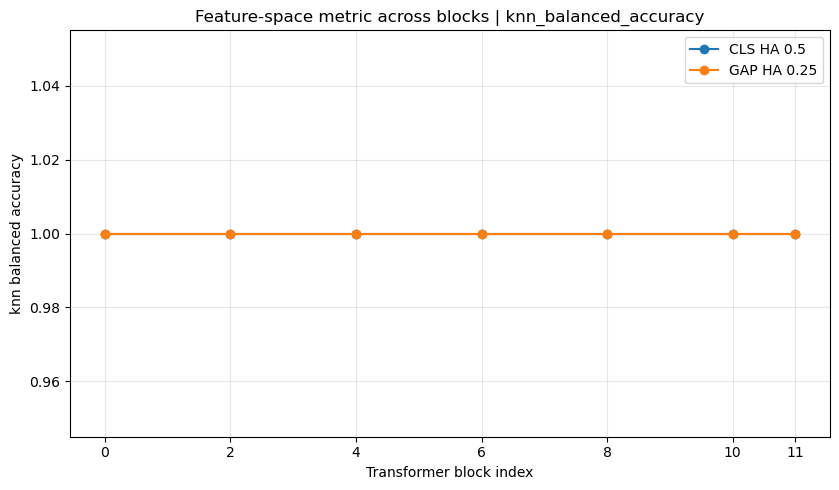

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/feature_metric_curve_knn_balanced_accuracy.png


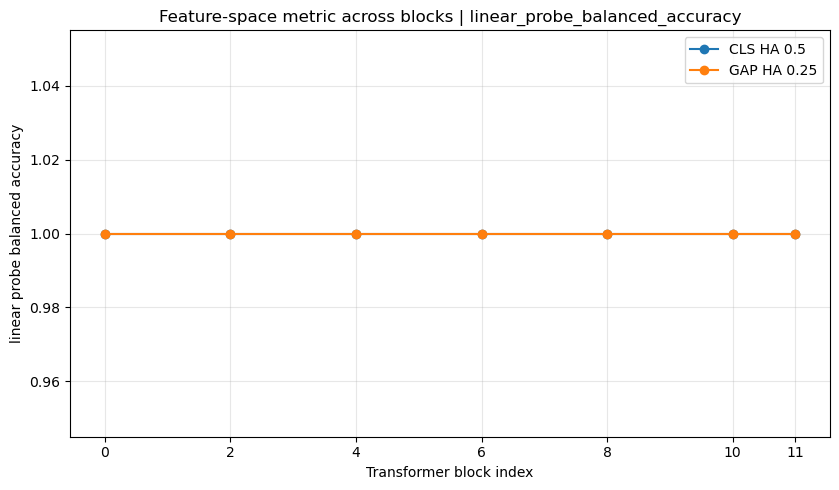

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/feature_metric_curve_linear_probe_balanced_accuracy.png


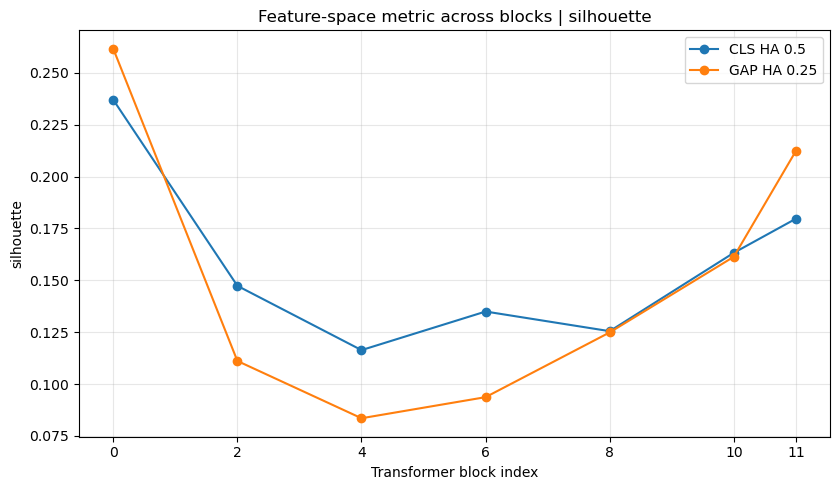

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/feature_metric_curve_silhouette.png


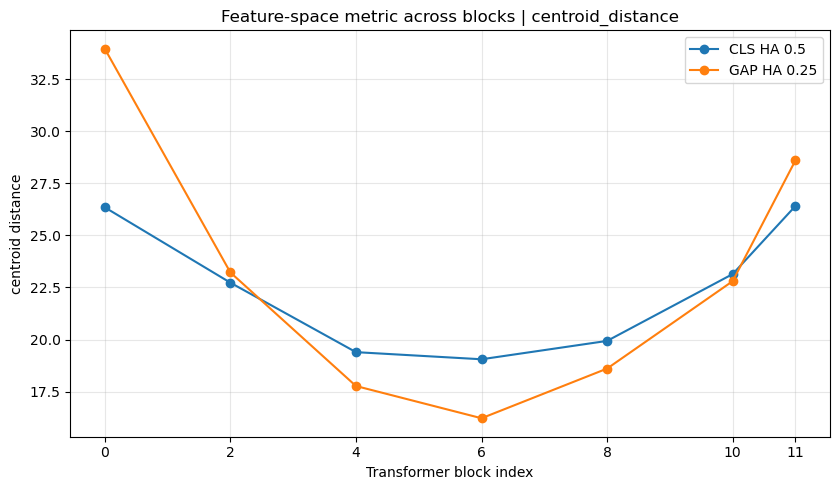

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/feature_metric_curve_centroid_distance.png


In [7]:
def plot_metric_curves(metric_df, metric="knn_balanced_accuracy"):
    plt.figure(figsize=(8.5, 5))
    for short_name, group in metric_df.groupby("short_name"):
        group = group.copy()
        group["resolved_index"] = group["block"].apply(lambda b: 12 + b if b < 0 else b)
        group = group.sort_values("resolved_index")
        label = group["model"].iloc[0]
        plt.plot(group["resolved_index"], group[metric], marker="o", label=label)
    plt.xlabel("Transformer block index")
    plt.ylabel(metric.replace("_", " "))
    plt.title(f"Feature-space metric across blocks | {metric}")
    plt.xticks(sorted({12 + b if b < 0 else b for b in SELECTED_BLOCKS}))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    out_path = OUT_ROOT / f"feature_metric_curve_{metric}.png"
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

for metric in ["knn_balanced_accuracy", "linear_probe_balanced_accuracy", "silhouette", "centroid_distance"]:
    plot_metric_curves(feature_metrics_df, metric=metric)


## 5. t-SNE and UMAP embeddings

Recommended plots:
- true label: do MEL/NV separate?
- prediction/correctness: where are failures?
- MEL probability: are uncertain points between groups?


In [8]:
def reduce_for_visualization(X, method="tsne", seed=42):
    X = np.asarray(X)
    Xs = StandardScaler().fit_transform(X)

    if Xs.shape[1] > PCA_DIM_BEFORE_TSNE:
        pca = PCA(n_components=PCA_DIM_BEFORE_TSNE, random_state=seed)
        X_in = pca.fit_transform(Xs)
    else:
        X_in = Xs

    if method == "tsne":
        n = X_in.shape[0]
        perplexity = min(TSNE_PERPLEXITY, max(5, (n - 1) // 3))
        reducer = TSNE(
            n_components=2,
            perplexity=perplexity,
            init="pca",
            learning_rate="auto",
            random_state=seed,
        )
        return reducer.fit_transform(X_in)

    if method == "umap":
        try:
            import umap
        except Exception as e:
            print("UMAP skipped. Install with: pip install umap-learn")
            print("Reason:", e)
            return None
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=15,
            min_dist=0.1,
            metric="euclidean",
            random_state=seed,
        )
        return reducer.fit_transform(X_in)

    raise ValueError(method)


def make_embedding_df(pack, block, method="tsne"):
    X = pack["features"][block]
    emb = reduce_for_visualization(X, method=method, seed=SEED)
    if emb is None:
        return None
    out = pack["meta"].copy()
    out["x"] = emb[:, 0]
    out["y"] = emb[:, 1]
    out["block"] = block
    out["method"] = method
    out["model"] = pack["scenario"]["name"]
    out["short_name"] = pack["scenario"]["short_name"]
    out["pooling"] = pack["scenario"]["pooling_name"]
    out["feature_mode"] = FEATURE_MODE
    return out


# Choose blocks to visualize as actual plots.
# Keep this small for readability.
VIS_BLOCKS = [-1, -4, -10]
VIS_BLOCKS = [b for b in VIS_BLOCKS if b in SELECTED_BLOCKS]

EMBEDDINGS = []
for short_name, pack in FEATURE_PACKS.items():
    for block in VIS_BLOCKS:
        if RUN_TSNE:
            print(f"Computing t-SNE: {short_name} block {block}")
            edf = make_embedding_df(pack, block, method="tsne")
            if edf is not None:
                EMBEDDINGS.append(edf)
        if RUN_UMAP:
            print(f"Computing UMAP: {short_name} block {block}")
            edf = make_embedding_df(pack, block, method="umap")
            if edf is not None:
                EMBEDDINGS.append(edf)

if EMBEDDINGS:
    embeddings_df = pd.concat(EMBEDDINGS, axis=0).reset_index(drop=True)
    embeddings_path = OUT_ROOT / "embeddings_tsne_umap.csv"
    embeddings_df.to_csv(embeddings_path, index=False)
    print("Saved:", embeddings_path)
    display(embeddings_df.head())
else:
    embeddings_df = pd.DataFrame()
    print("No embeddings computed.")


Computing t-SNE: cls_ha05 block -1
Computing UMAP: cls_ha05 block -1
Computing t-SNE: cls_ha05 block -4
Computing UMAP: cls_ha05 block -4
Computing t-SNE: cls_ha05 block -10
Computing UMAP: cls_ha05 block -10
Computing t-SNE: gap_ha025 block -1
Computing UMAP: gap_ha025 block -1
Computing t-SNE: gap_ha025 block -4
Computing UMAP: gap_ha025 block -4
Computing t-SNE: gap_ha025 block -10
Computing UMAP: gap_ha025 block -10
Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/embeddings_tsne_umap.csv


,image_id,gt_label,y_true,y_pred,pred_label,correct,mel_probability,nv_probability,prediction_confidence,x,y,block,method,model,short_name,pooling,feature_mode
0,ISIC_0024459,MEL,0,0,MEL,True,0.998252,0.001748,0.998252,-47.291702,-14.626750,-1,tsne,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling
1,ISIC_0024571,MEL,0,0,MEL,True,0.998144,0.001856,0.998144,-52.785759,-3.122299,-1,tsne,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling
2,ISIC_0024624,MEL,0,0,MEL,True,0.988189,0.011811,0.988189,-52.006786,-9.780886,-1,tsne,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling
3,ISIC_0024640,MEL,0,0,MEL,True,0.997442,0.002558,0.997442,-48.099926,-15.675417,-1,tsne,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling
4,ISIC_0024756,MEL,0,0,MEL,True,0.921773,0.078227,0.921773,-44.553661,5.437288,-1,tsne,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling


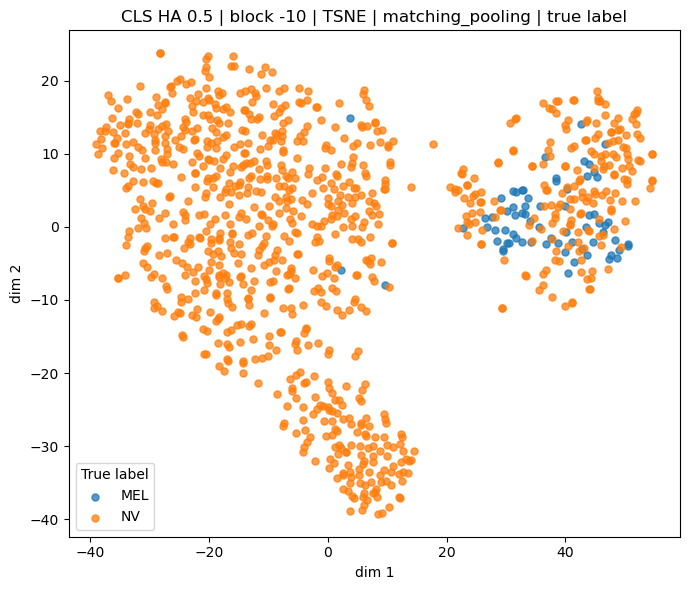

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/cls_ha05/tsne_block_-10/embedding_true_label.png


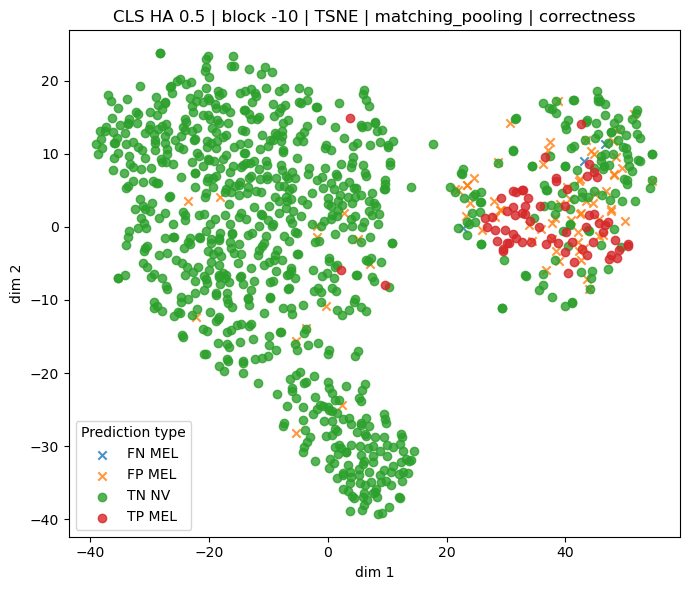

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/cls_ha05/tsne_block_-10/embedding_correctness.png


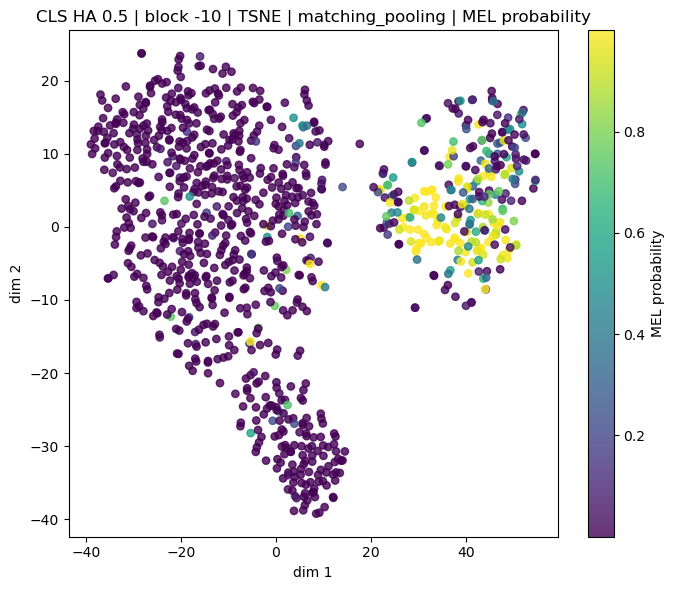

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/cls_ha05/tsne_block_-10/embedding_mel_probability.png


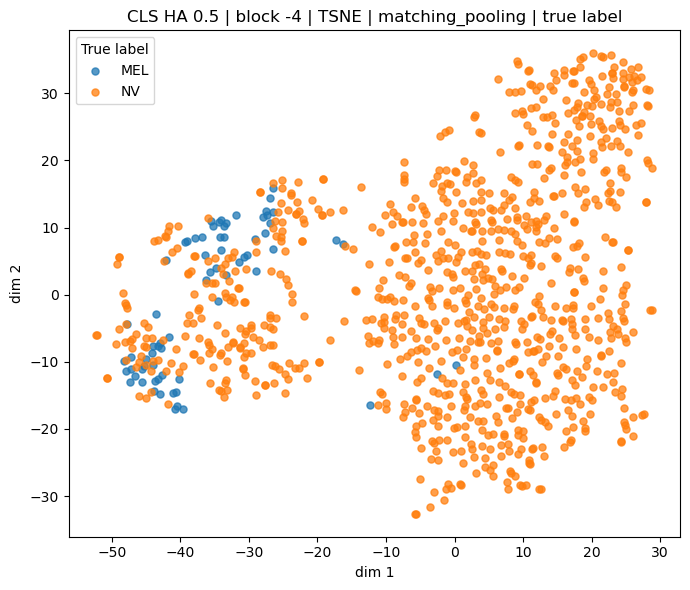

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/cls_ha05/tsne_block_-4/embedding_true_label.png


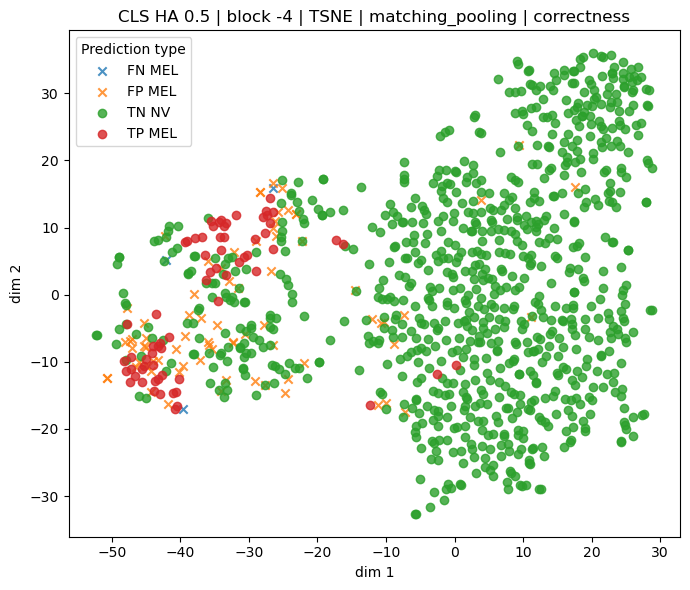

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/cls_ha05/tsne_block_-4/embedding_correctness.png


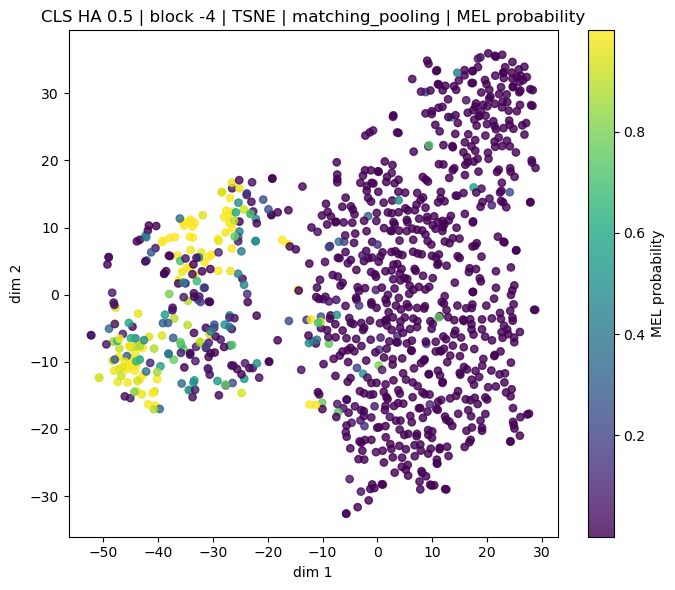

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/cls_ha05/tsne_block_-4/embedding_mel_probability.png


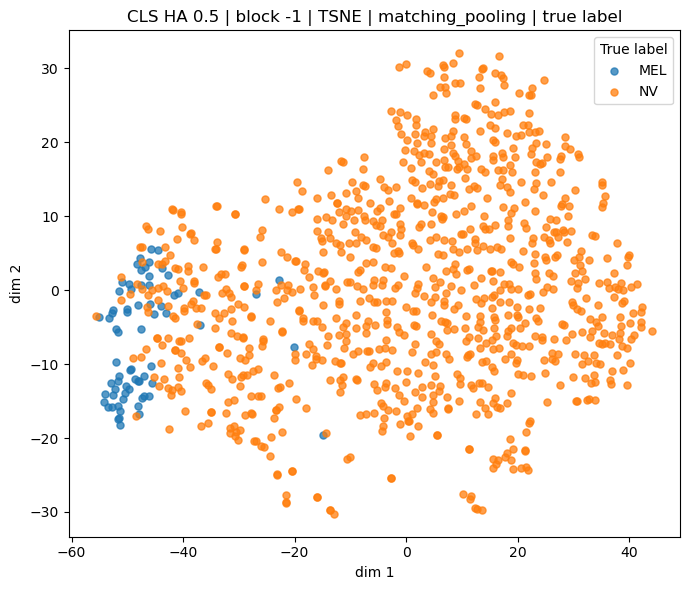

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/cls_ha05/tsne_block_-1/embedding_true_label.png


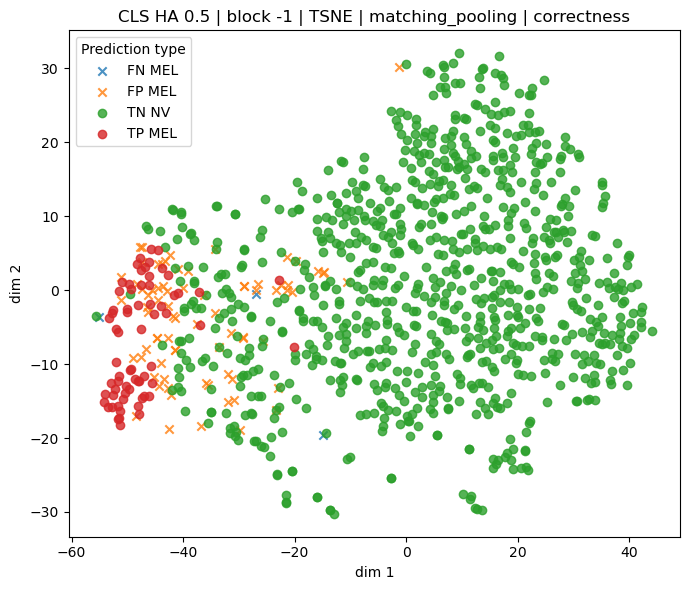

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/cls_ha05/tsne_block_-1/embedding_correctness.png


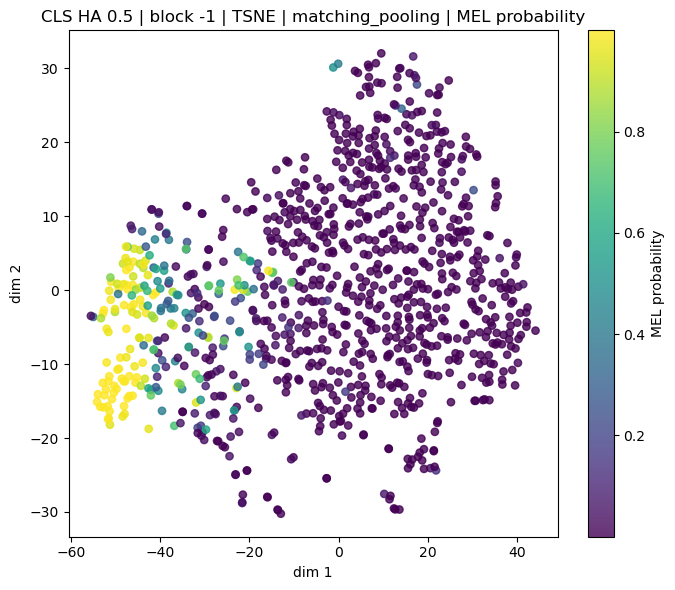

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/cls_ha05/tsne_block_-1/embedding_mel_probability.png


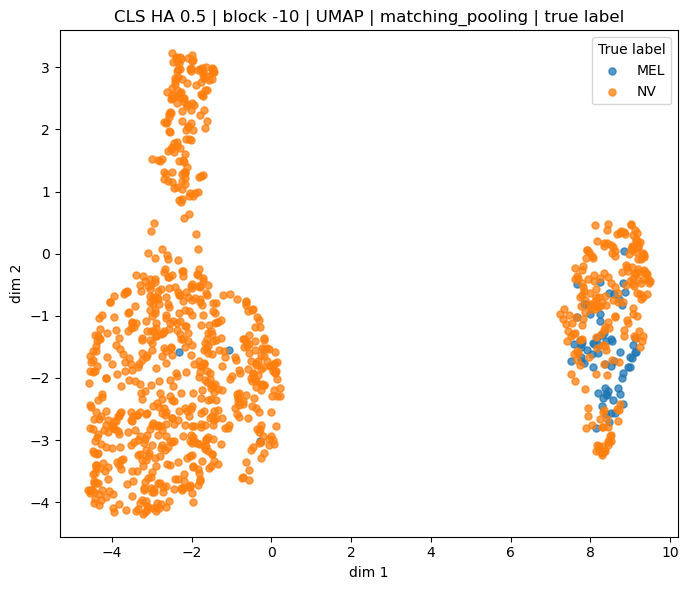

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/cls_ha05/umap_block_-10/embedding_true_label.png


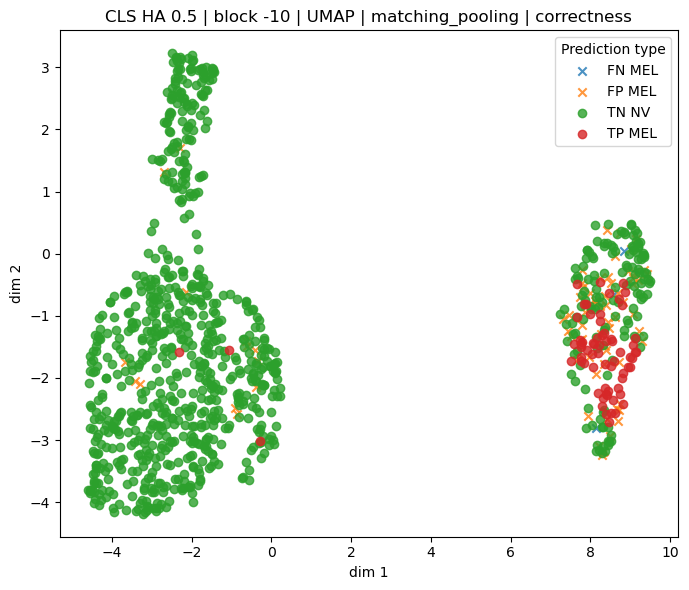

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/cls_ha05/umap_block_-10/embedding_correctness.png


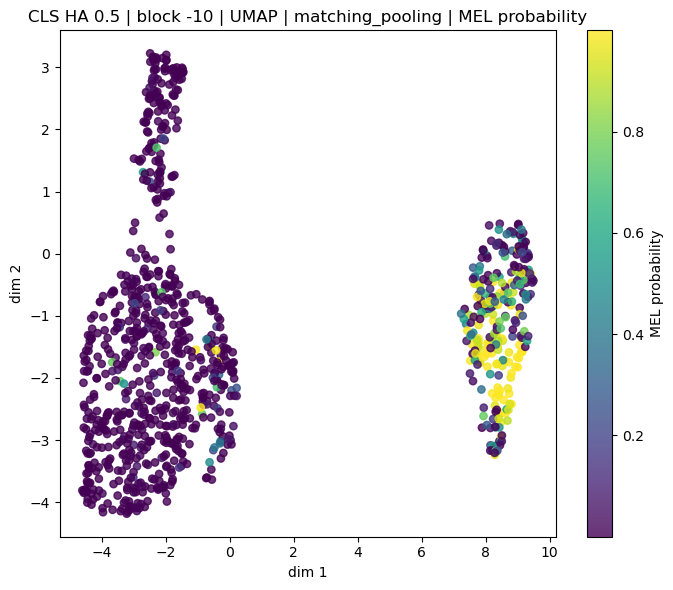

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/cls_ha05/umap_block_-10/embedding_mel_probability.png


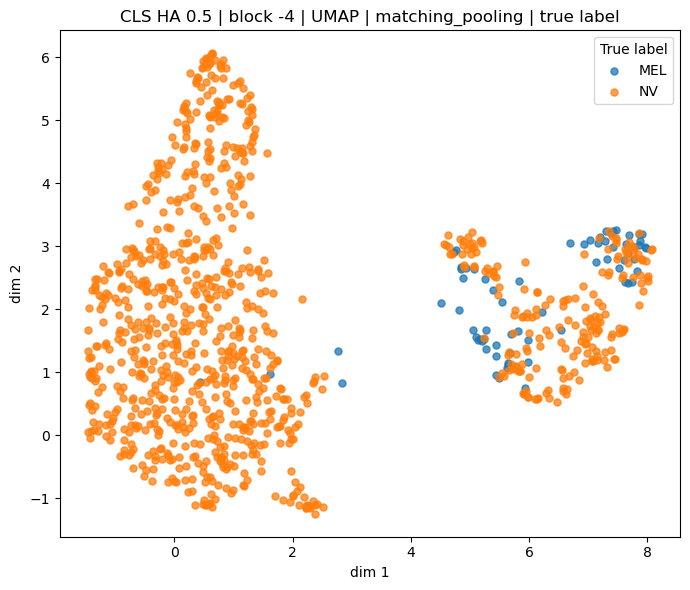

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/cls_ha05/umap_block_-4/embedding_true_label.png


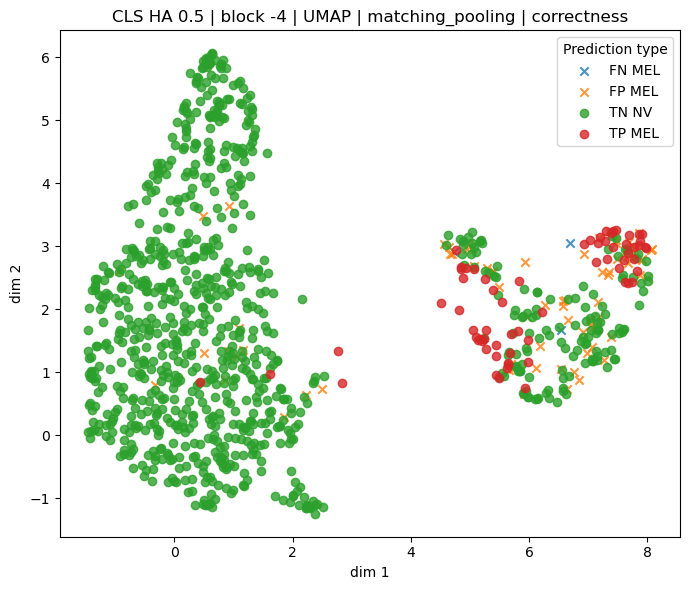

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/cls_ha05/umap_block_-4/embedding_correctness.png


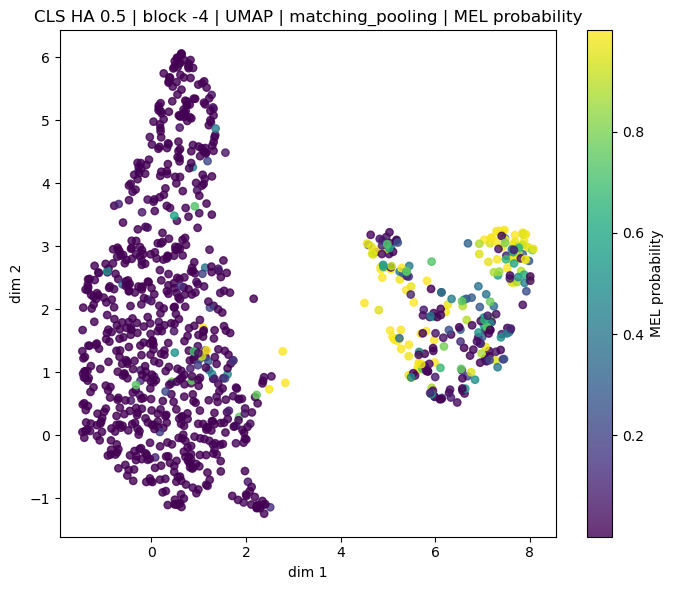

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/cls_ha05/umap_block_-4/embedding_mel_probability.png


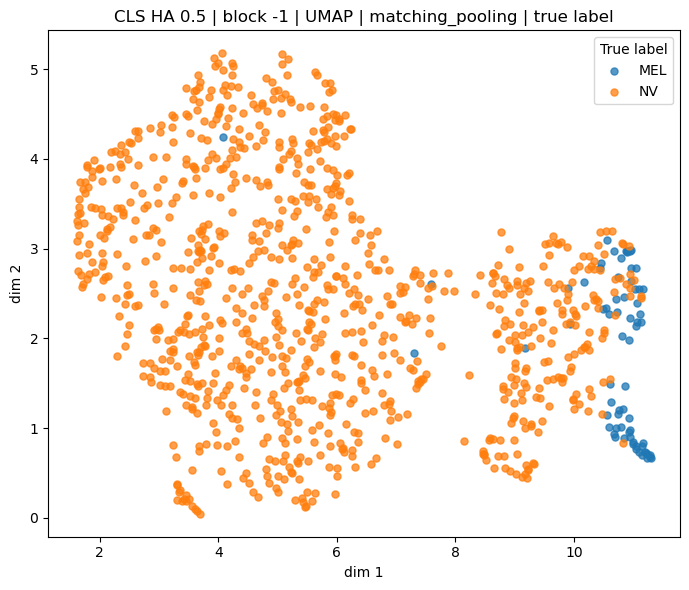

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/cls_ha05/umap_block_-1/embedding_true_label.png


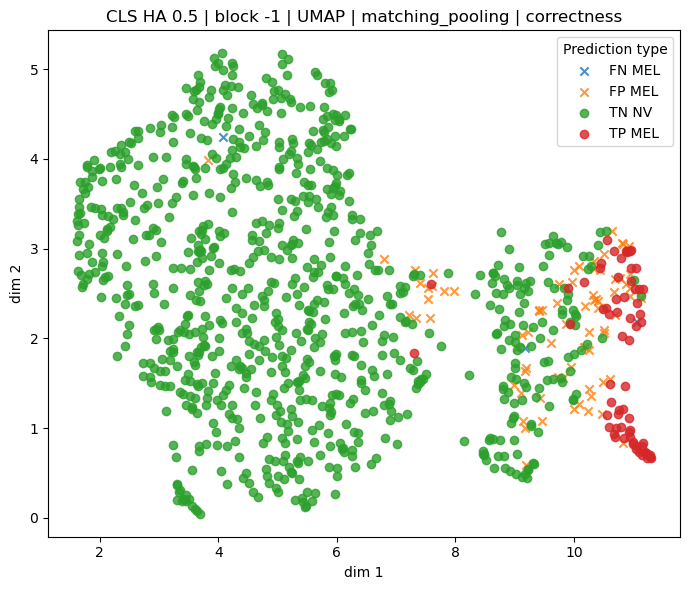

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/cls_ha05/umap_block_-1/embedding_correctness.png


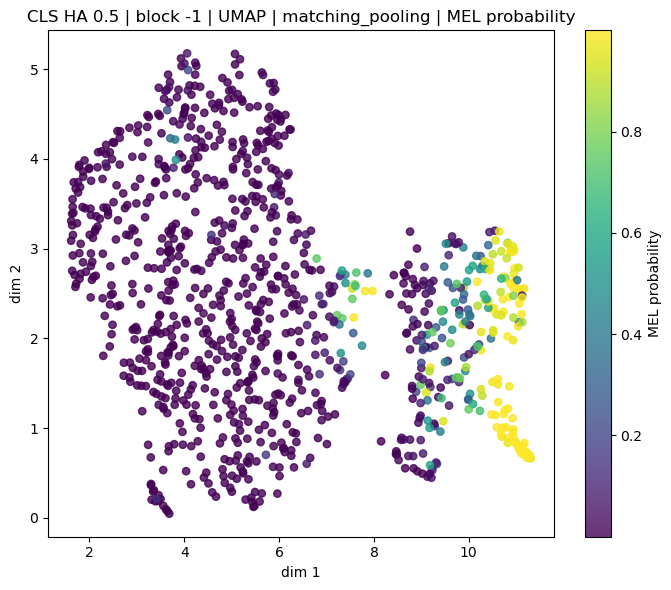

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/cls_ha05/umap_block_-1/embedding_mel_probability.png


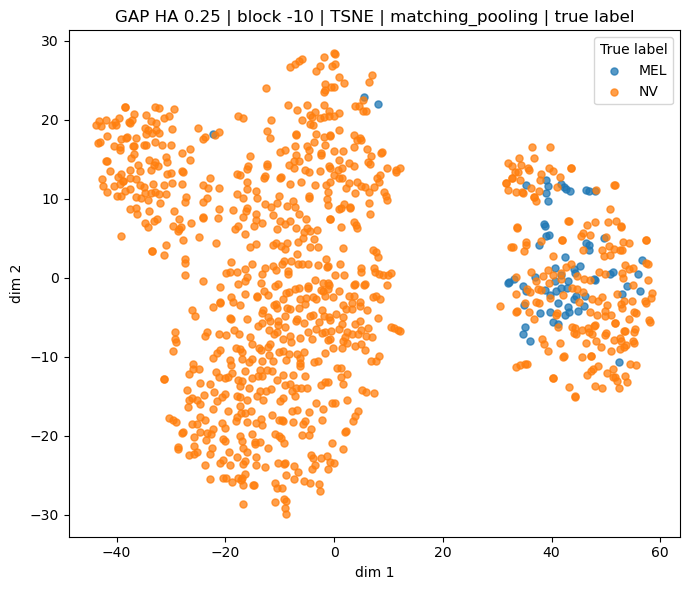

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/gap_ha025/tsne_block_-10/embedding_true_label.png


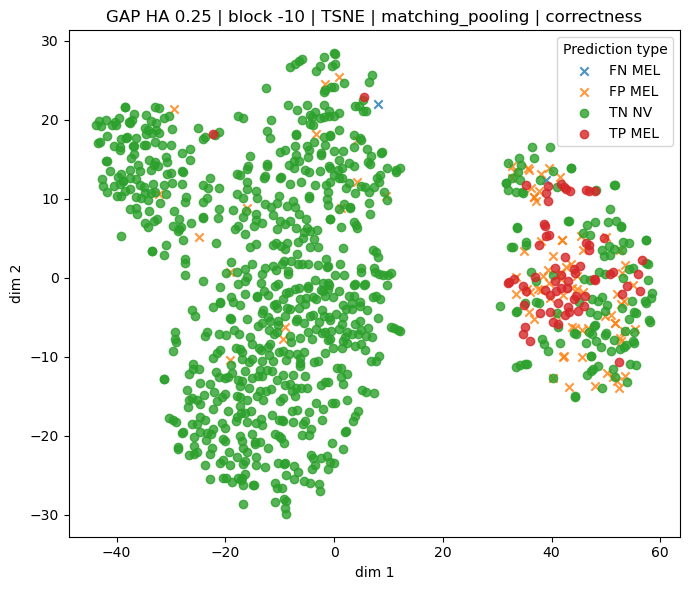

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/gap_ha025/tsne_block_-10/embedding_correctness.png


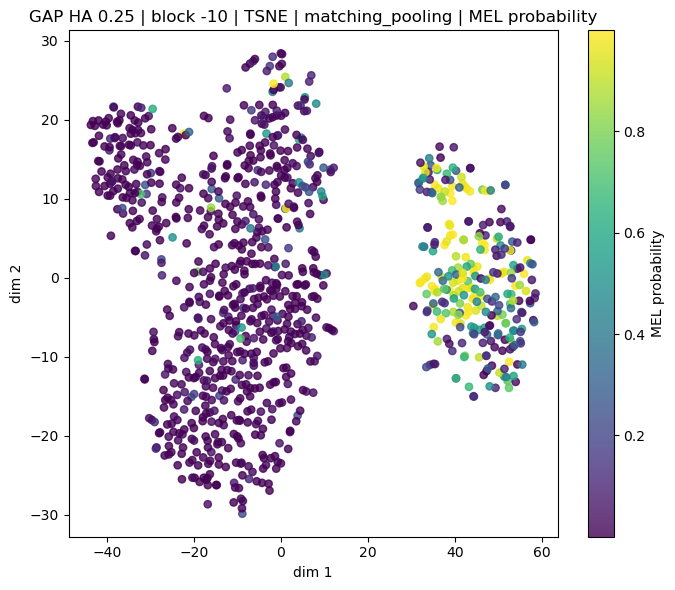

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/gap_ha025/tsne_block_-10/embedding_mel_probability.png


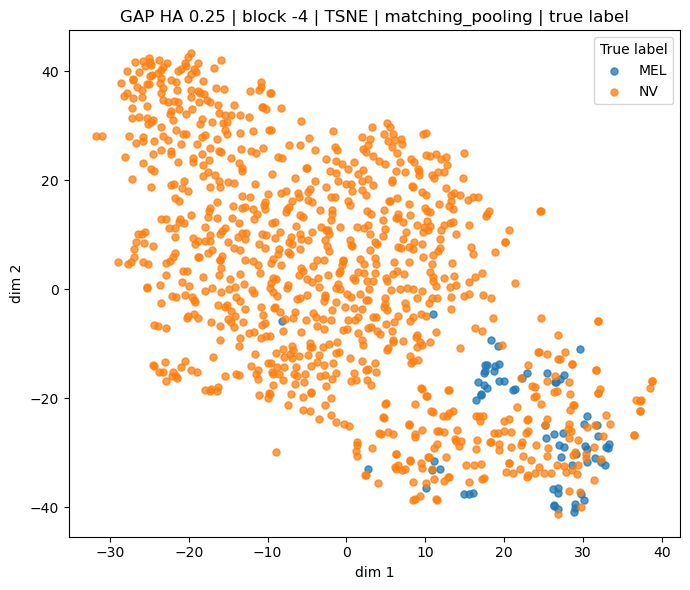

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/gap_ha025/tsne_block_-4/embedding_true_label.png


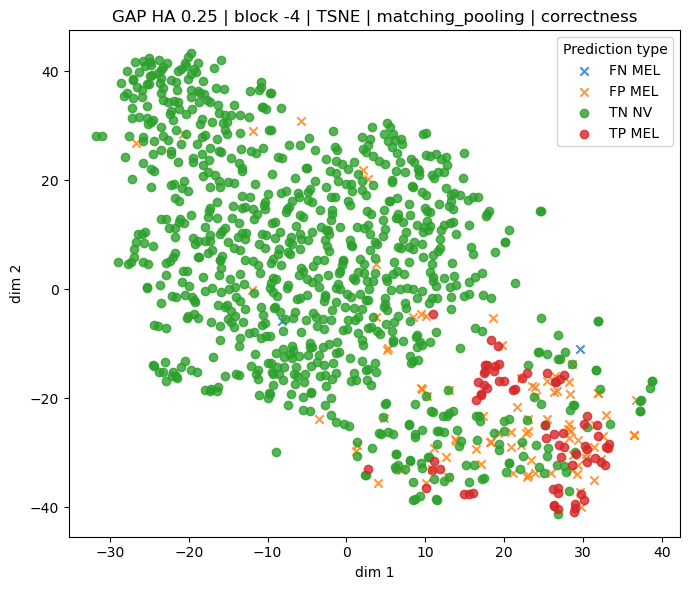

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/gap_ha025/tsne_block_-4/embedding_correctness.png


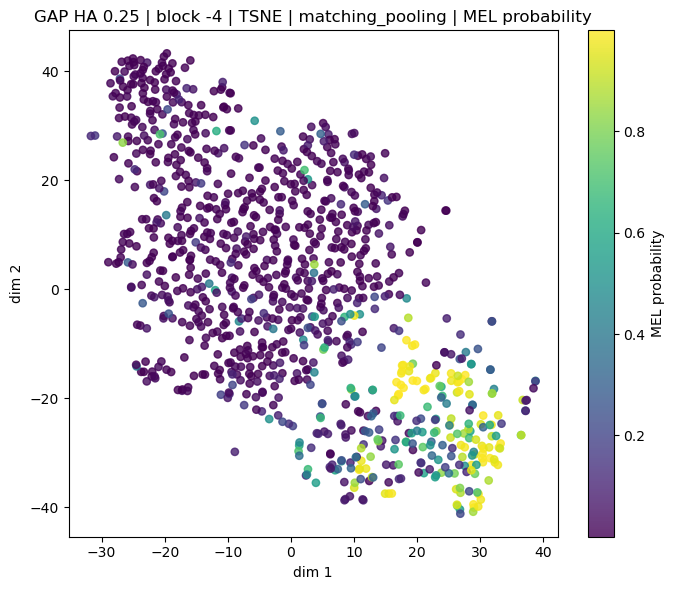

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/gap_ha025/tsne_block_-4/embedding_mel_probability.png


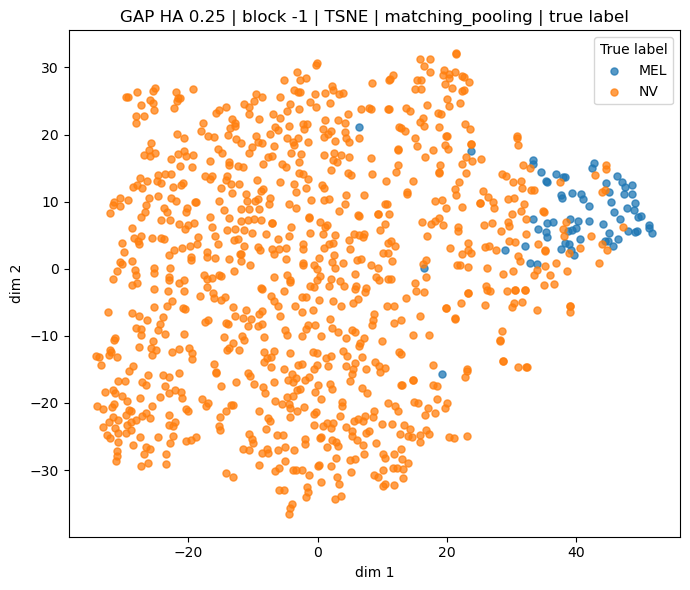

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/gap_ha025/tsne_block_-1/embedding_true_label.png


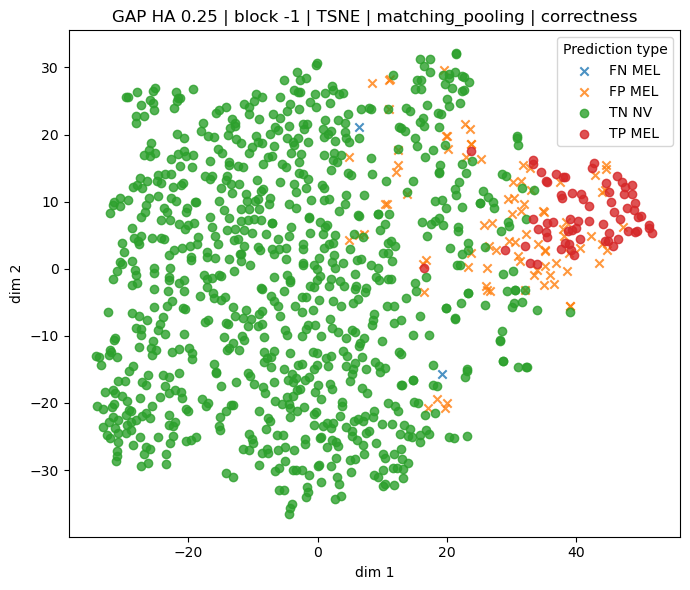

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/gap_ha025/tsne_block_-1/embedding_correctness.png


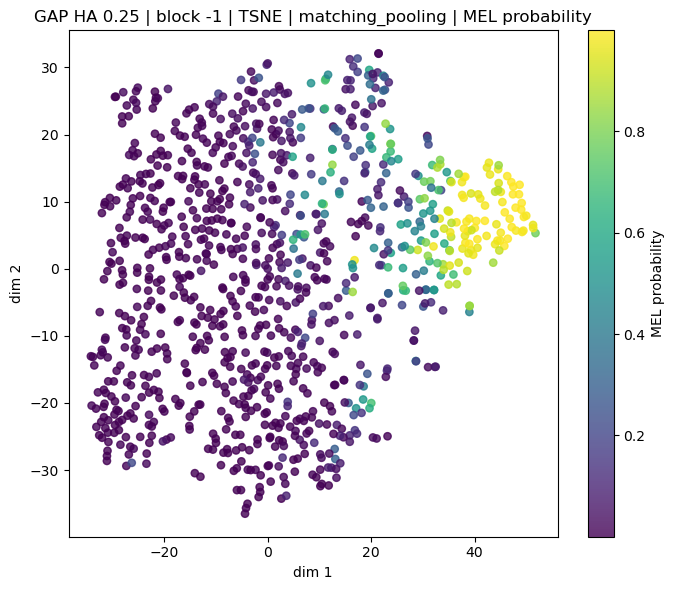

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/gap_ha025/tsne_block_-1/embedding_mel_probability.png


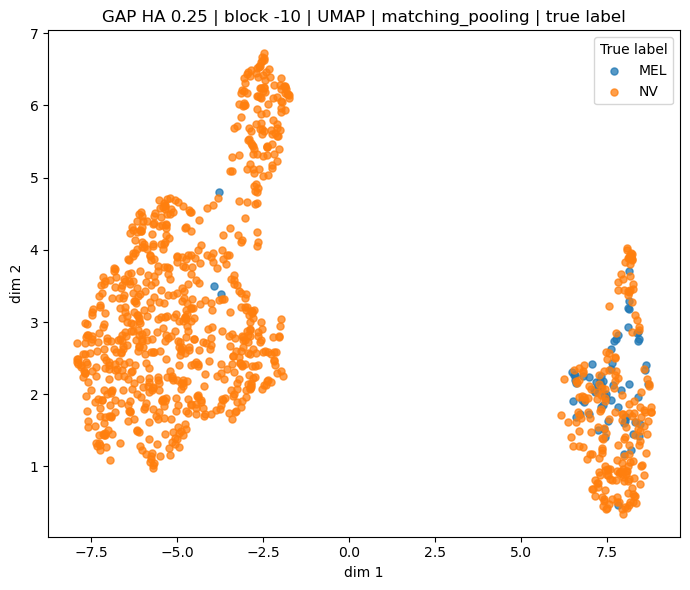

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/gap_ha025/umap_block_-10/embedding_true_label.png


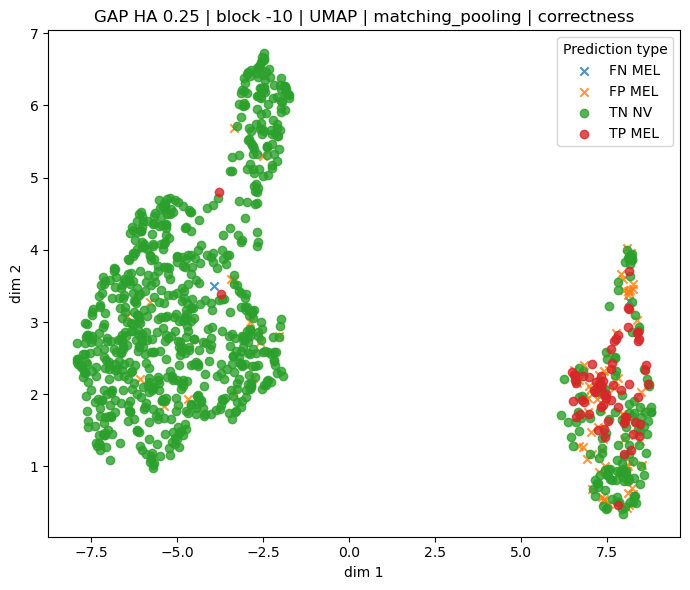

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/gap_ha025/umap_block_-10/embedding_correctness.png


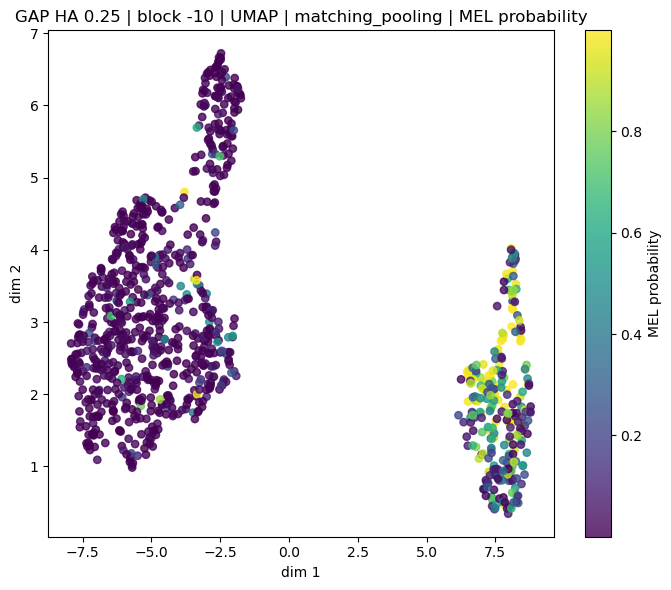

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/gap_ha025/umap_block_-10/embedding_mel_probability.png


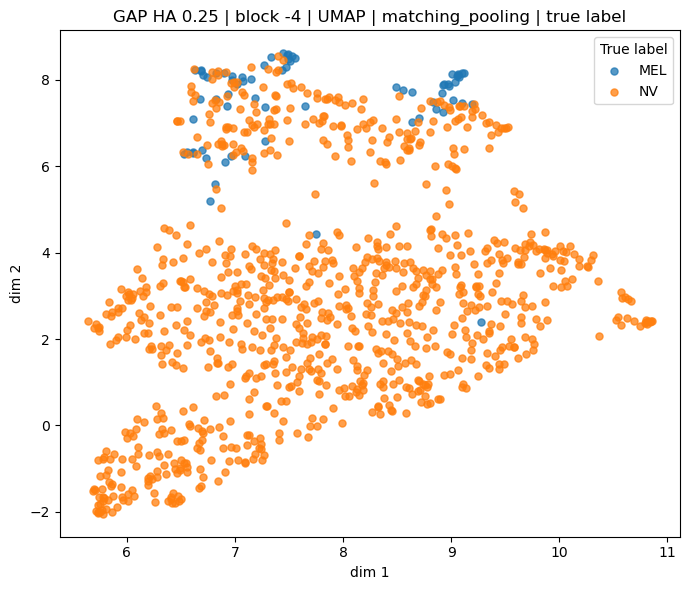

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/gap_ha025/umap_block_-4/embedding_true_label.png


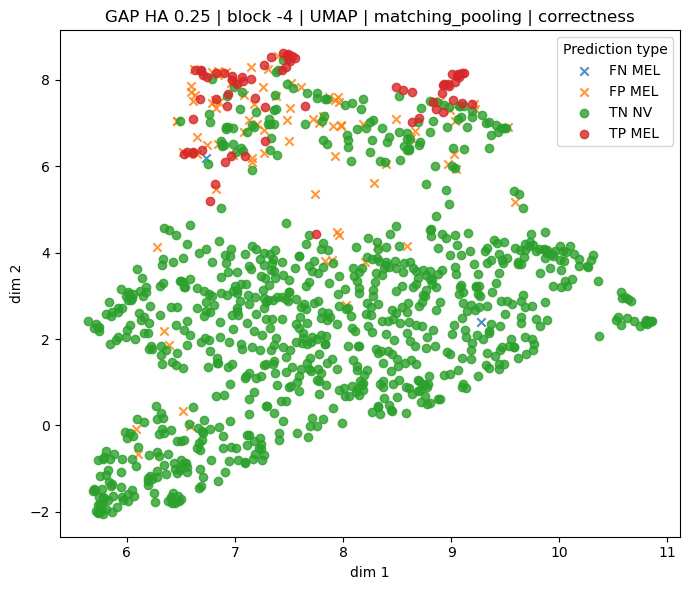

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/gap_ha025/umap_block_-4/embedding_correctness.png


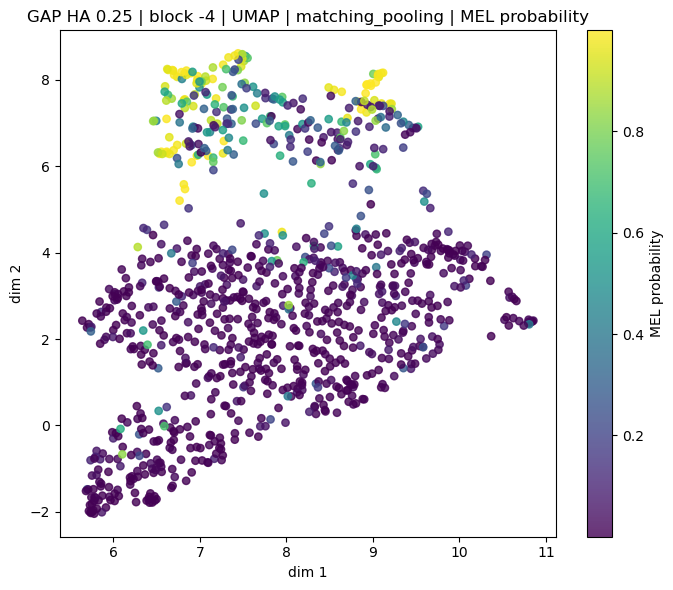

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/gap_ha025/umap_block_-4/embedding_mel_probability.png


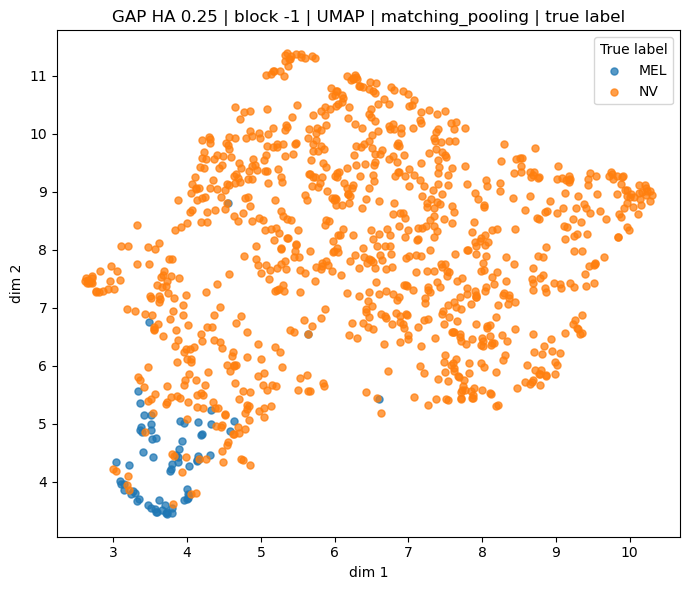

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/gap_ha025/umap_block_-1/embedding_true_label.png


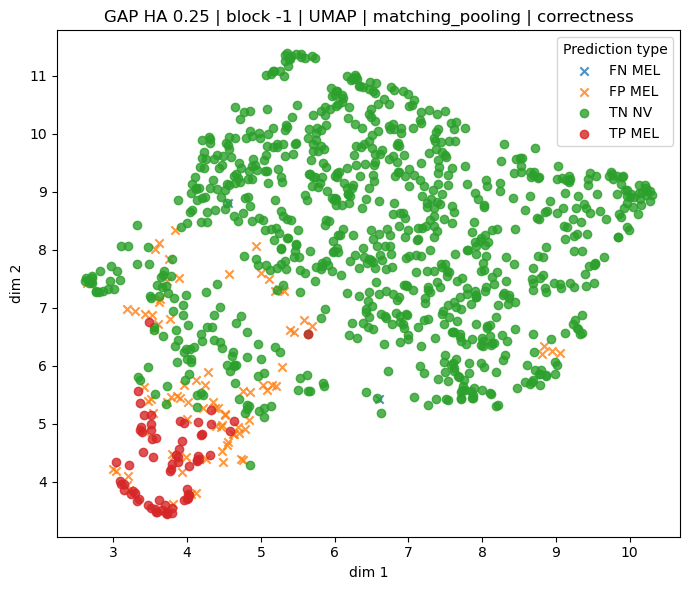

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/gap_ha025/umap_block_-1/embedding_correctness.png


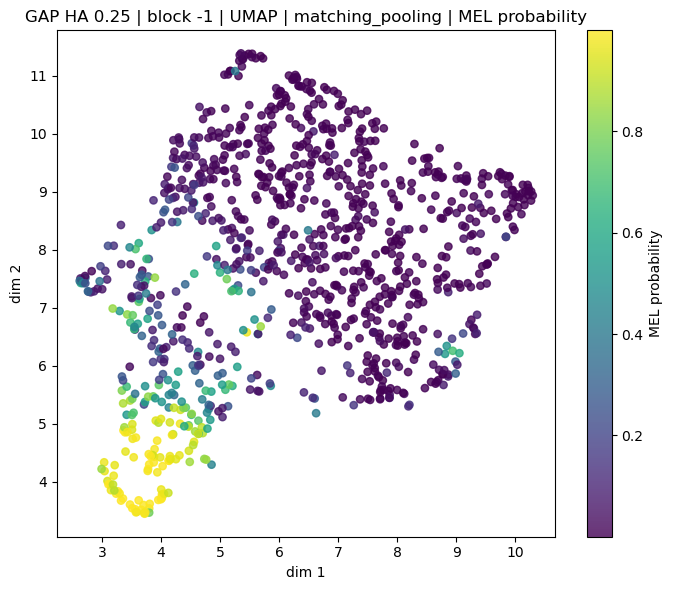

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/gap_ha025/umap_block_-1/embedding_mel_probability.png


In [9]:
def plot_embedding_true_label(edf, title, out_path):
    plt.figure(figsize=(7, 6))
    for label_name, group in edf.groupby("gt_label"):
        plt.scatter(group["x"], group["y"], s=26, alpha=0.75, label=label_name)
    plt.xlabel("dim 1")
    plt.ylabel("dim 2")
    plt.title(title)
    plt.legend(title="True label")
    plt.tight_layout()
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


def plot_embedding_correctness(edf, title, out_path):
    # Four clinically useful groups.
    def group_name(row):
        if row["y_true"] == 0 and row["y_pred"] == 0:
            return "TP MEL"
        if row["y_true"] == 1 and row["y_pred"] == 1:
            return "TN NV"
        if row["y_true"] == 1 and row["y_pred"] == 0:
            return "FP MEL"
        if row["y_true"] == 0 and row["y_pred"] == 1:
            return "FN MEL"
        return "other"

    tmp = edf.copy()
    tmp["case_type"] = tmp.apply(group_name, axis=1)

    plt.figure(figsize=(7, 6))
    for case_type, group in tmp.groupby("case_type"):
        marker = "x" if case_type.startswith("F") else "o"
        plt.scatter(group["x"], group["y"], s=36, alpha=0.80, marker=marker, label=case_type)
    plt.xlabel("dim 1")
    plt.ylabel("dim 2")
    plt.title(title)
    plt.legend(title="Prediction type")
    plt.tight_layout()
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


def plot_embedding_mel_probability(edf, title, out_path):
    plt.figure(figsize=(7, 6))
    sc = plt.scatter(edf["x"], edf["y"], c=edf["mel_probability"], s=28, alpha=0.80)
    plt.colorbar(sc, label="MEL probability")
    plt.xlabel("dim 1")
    plt.ylabel("dim 2")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


if len(embeddings_df) > 0:
    for (short_name, method, block), edf in embeddings_df.groupby(["short_name", "method", "block"]):
        model_name = edf["model"].iloc[0]
        out_dir = OUT_ROOT / short_name / f"{method}_block_{block}"
        out_dir.mkdir(parents=True, exist_ok=True)

        title_base = f"{model_name} | block {block} | {method.upper()} | {FEATURE_MODE}"

        plot_embedding_true_label(
            edf,
            title=f"{title_base} | true label",
            out_path=out_dir / "embedding_true_label.png",
        )
        plot_embedding_correctness(
            edf,
            title=f"{title_base} | correctness",
            out_path=out_dir / "embedding_correctness.png",
        )
        plot_embedding_mel_probability(
            edf,
            title=f"{title_base} | MEL probability",
            out_path=out_dir / "embedding_mel_probability.png",
        )


## 6. Side-by-side comparison plot

This gives one compact figure comparing CLS vs GAP for a selected block and method.


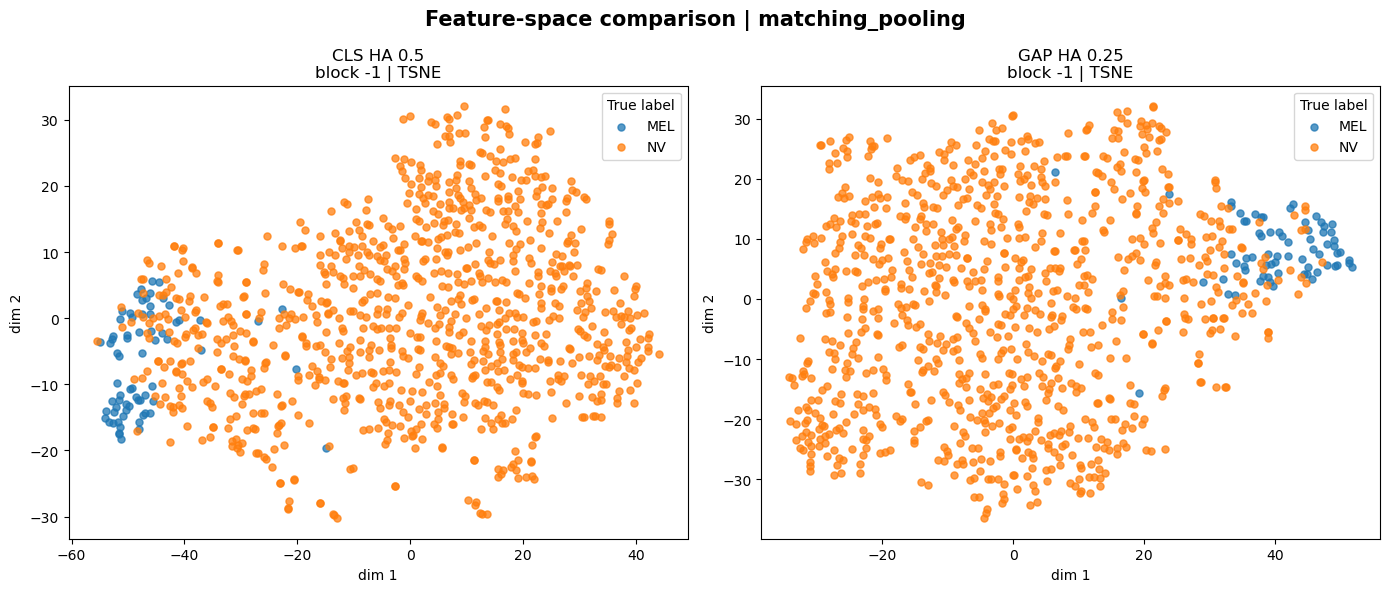

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/side_by_side_tsne_block_-1_true_label.png


In [10]:
COMPARE_METHOD = "tsne"  # "tsne" or "umap"
COMPARE_BLOCK = -1


def plot_side_by_side_true_label(embeddings_df, method="tsne", block=-1):
    sub = embeddings_df[(embeddings_df["method"] == method) & (embeddings_df["block"] == block)].copy()
    if len(sub) == 0:
        print("No embedding for", method, block)
        return

    short_names = list(sub["short_name"].drop_duplicates())
    fig, axes = plt.subplots(1, len(short_names), figsize=(7 * len(short_names), 6), squeeze=False)
    axes = axes.reshape(-1)

    for ax, short_name in zip(axes, short_names):
        edf = sub[sub["short_name"] == short_name]
        model_name = edf["model"].iloc[0]
        for label_name, group in edf.groupby("gt_label"):
            ax.scatter(group["x"], group["y"], s=26, alpha=0.75, label=label_name)
        ax.set_title(f"{model_name}\nblock {block} | {method.upper()}")
        ax.set_xlabel("dim 1")
        ax.set_ylabel("dim 2")
        ax.legend(title="True label")

    fig.suptitle(f"Feature-space comparison | {FEATURE_MODE}", fontsize=15, fontweight="bold")
    plt.tight_layout()

    out_path = OUT_ROOT / f"side_by_side_{method}_block_{block}_true_label.png"
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


if len(embeddings_df) > 0:
    plot_side_by_side_true_label(embeddings_df, method=COMPARE_METHOD, block=COMPARE_BLOCK)


## 7. Nearest-neighbor examples

This is useful for dermatologist discussions:
- false negatives: melanomas predicted as nevus
- false positives: nevi predicted as melanoma
- ambiguous low-confidence cases

The table shows whether nearest neighbors in feature space share the same label.


In [11]:
def nearest_neighbor_table(pack, block=-1, query_case="errors", n_queries=8, k=5):
    X = pack["features"][block]
    meta = pack["meta"].copy().reset_index(drop=True)
    Xs = StandardScaler().fit_transform(X)

    nn = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
    nn.fit(Xs)

    if query_case == "errors":
        query_idx = meta.index[~meta["correct"]].tolist()
    elif query_case == "false_negatives":
        query_idx = meta.index[(meta["y_true"] == 0) & (meta["y_pred"] == 1)].tolist()
    elif query_case == "false_positives":
        query_idx = meta.index[(meta["y_true"] == 1) & (meta["y_pred"] == 0)].tolist()
    elif query_case == "low_confidence":
        query_idx = meta.sort_values("prediction_confidence").index.tolist()
    else:
        raise ValueError(query_case)

    query_idx = query_idx[:n_queries]
    rows = []

    for qi in query_idx:
        distances, indices = nn.kneighbors(Xs[qi:qi+1], n_neighbors=k + 1)
        distances = distances[0]
        indices = indices[0]

        # remove self
        neigh = [(int(i), float(d)) for i, d in zip(indices, distances) if int(i) != qi][:k]

        q = meta.iloc[qi]
        neighbor_labels = [meta.iloc[i]["gt_label"] for i, _ in neigh]
        same_label_fraction = np.mean([lbl == q["gt_label"] for lbl in neighbor_labels]) if neighbor_labels else np.nan

        rows.append({
            "query_image_id": q["image_id"],
            "query_gt": q["gt_label"],
            "query_pred": q["pred_label"],
            "query_correct": bool(q["correct"]),
            "query_mel_probability": float(q["mel_probability"]),
            "neighbor_image_ids": ", ".join(meta.iloc[i]["image_id"] for i, _ in neigh),
            "neighbor_gt_labels": ", ".join(neighbor_labels),
            "same_label_fraction": float(same_label_fraction),
        })

    return pd.DataFrame(rows)


NN_BLOCK = -1
nn_tables = []
for short_name, pack in FEATURE_PACKS.items():
    for query_case in ["errors", "false_negatives", "false_positives", "low_confidence"]:
        tab = nearest_neighbor_table(pack, block=NN_BLOCK, query_case=query_case, n_queries=8, k=KNN_K)
        tab.insert(0, "query_case", query_case)
        tab.insert(0, "model", pack["scenario"]["name"])
        tab.insert(0, "short_name", short_name)
        nn_tables.append(tab)

nearest_df = pd.concat(nn_tables, axis=0).reset_index(drop=True)
nearest_path = OUT_ROOT / f"nearest_neighbor_examples_block_{NN_BLOCK}.csv"
nearest_df.to_csv(nearest_path, index=False)
print("Saved:", nearest_path)
display(nearest_df)


Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/mel_nv/tsne_umap_feature_space/nearest_neighbor_examples_block_-1.csv


,short_name,model,query_case,query_image_id,query_gt,query_pred,query_correct,query_mel_probability,neighbor_image_ids,neighbor_gt_labels,same_label_fraction
0,cls_ha05,CLS HA 0.5,errors,ISIC_0024886,MEL,NV,False,0.320686,"ISIC_0024863, ISIC_0032295, ISIC_0028882, ISIC...","NV, NV, NV, MEL, MEL",0.4
1,cls_ha05,CLS HA 0.5,errors,ISIC_0028173,MEL,NV,False,0.041091,"ISIC_0029566, ISIC_0025120, ISIC_0030152, ISIC...","NV, NV, NV, NV, NV",0.0
2,cls_ha05,CLS HA 0.5,errors,ISIC_0030552,MEL,NV,False,0.314089,"ISIC_0033101, ISIC_0030479, ISIC_0033697, ISIC...","NV, NV, NV, NV, NV",0.0
3,cls_ha05,CLS HA 0.5,errors,ISIC_0024344,NV,MEL,False,0.994138,"ISIC_0025836, ISIC_0026150, ISIC_0033916, ISIC...","NV, MEL, NV, MEL, MEL",0.4
4,cls_ha05,CLS HA 0.5,errors,ISIC_0024416,NV,MEL,False,0.842511,"ISIC_0029089, ISIC_0026491, ISIC_0024716, ISIC...","MEL, NV, NV, NV, MEL",0.6
5,cls_ha05,CLS HA 0.5,errors,ISIC_0024620,NV,MEL,False,0.579481,"ISIC_0032340, ISIC_0031177, ISIC_0033735, ISIC...","NV, MEL, NV, NV, NV",0.8
6,cls_ha05,CLS HA 0.5,errors,ISIC_0024704,NV,MEL,False,0.786131,"ISIC_0027688, ISIC_0032340, ISIC_0031802, ISIC...","NV, NV, NV, NV, NV",1.0
7,cls_ha05,CLS HA 0.5,errors,ISIC_0024716,NV,MEL,False,0.908456,"ISIC_0026491, ISIC_0030625, ISIC_0030733, ISIC...","NV, NV, NV, NV, MEL",0.8
8,cls_ha05,CLS HA 0.5,false_negatives,ISIC_0024886,MEL,NV,False,0.320686,"ISIC_0024863, ISIC_0032295, ISIC_0028882, ISIC...","NV, NV, NV, MEL, MEL",0.4
9,cls_ha05,CLS HA 0.5,false_negatives,ISIC_0028173,MEL,NV,False,0.041091,"ISIC_0029566, ISIC_0025120, ISIC_0030152, ISIC...","NV, NV, NV, NV, NV",0.0


## 8. Final numeric recommendation from feature-space metrics

Use this only as supportive evidence. The final model/block choice should still prioritize:
1. classification performance,
2. lesion alignment metrics from notebook 02,
3. qualitative CAM readability,
4. perturbation confidence test,
5. dermatologist judgement.


In [12]:
print("\n" + "=" * 100)
print("FEATURE-SPACE RECOMMENDATION")
print("=" * 100)

ranked = feature_metrics_df.copy()
ranked["feature_score"] = (
    0.45 * ranked["knn_balanced_accuracy"]
    + 0.45 * ranked["linear_probe_balanced_accuracy"]
    + 0.10 * ranked["silhouette"].fillna(0)
)

ranked = ranked.sort_values(["model", "feature_score"], ascending=[True, False])
display(ranked)

for model_name, sub in ranked.groupby("model"):
    best = sub.iloc[0]
    print(
        f"{model_name}: feature-space best block = {int(best['block'])} "
        f"(score={best['feature_score']:.3f}, "
        f"kNN balanced acc={best['knn_balanced_accuracy']:.3f}, "
        f"linear probe balanced acc={best['linear_probe_balanced_accuracy']:.3f}, "
        f"silhouette={best['silhouette']:.3f})."
    )

print("=" * 100)
print("Important: this helps understand representation separation. It should not override CAM lesion-alignment and clinical readability.")
print("=" * 100)

ranked.to_csv(OUT_ROOT / "feature_space_ranked_blocks.csv", index=False)



FEATURE-SPACE RECOMMENDATION


,model,short_name,pooling,feature_mode,block,knn_accuracy,knn_balanced_accuracy,linear_probe_accuracy,linear_probe_balanced_accuracy,silhouette,centroid_distance,feature_score
6,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling,-12,1.0,1.0,1.0,1.0,0.237016,26.343483,0.923702
0,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling,-1,1.0,1.0,1.0,1.0,0.179701,26.410072,0.917970
1,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling,-2,1.0,1.0,1.0,1.0,0.163271,23.141247,0.916327
5,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling,-10,1.0,1.0,1.0,1.0,0.147353,22.727320,0.914735
3,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling,-6,1.0,1.0,1.0,1.0,0.134970,19.051201,0.913497
2,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling,-4,1.0,1.0,1.0,1.0,0.125496,19.932720,0.912550
4,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling,-8,1.0,1.0,1.0,1.0,0.116370,19.393196,0.911637
13,GAP HA 0.25,gap_ha025,GAP / mean pooling,matching_pooling,-12,1.0,1.0,1.0,1.0,0.261606,33.954559,0.926161
7,GAP HA 0.25,gap_ha025,GAP / mean pooling,matching_pooling,-1,1.0,1.0,1.0,1.0,0.212341,28.600689,0.921234
8,GAP HA 0.25,gap_ha025,GAP / mean pooling,matching_pooling,-2,1.0,1.0,1.0,1.0,0.161363,22.801706,0.916136


CLS HA 0.5: feature-space best block = -12 (score=0.924, kNN balanced acc=1.000, linear probe balanced acc=1.000, silhouette=0.237).
GAP HA 0.25: feature-space best block = -12 (score=0.926, kNN balanced acc=1.000, linear probe balanced acc=1.000, silhouette=0.262).
Important: this helps understand representation separation. It should not override CAM lesion-alignment and clinical readability.


## 9. Suggested thesis wording

Possible wording:

> To complement the CAM analysis, we visualized image-level PanDerm representations using t-SNE/UMAP. This analysis provides an exploratory view of whether melanoma and nevus images are separated in the learned representation space. Later transformer blocks showed stronger class separation according to k-nearest-neighbor and linear-probe metrics. However, these visualizations were used only as supporting evidence, since low-dimensional embeddings do not establish clinical meaningfulness. The clinical plausibility of highlighted regions was evaluated separately using lesion alignment, perturbation analysis, and dermatologist feedback.
